# Support vector machine (SVM)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Задача классификации

Пусть задано множество объектов $X$ и конечное множество меток классов $Y$. Будем изначально рассматрвиать бинарную классификацию $y_i \in \{-1, +1\}$.

Мы хотим обучить линейную модель так, чтобы плоскость, которую она задаёт, как можно лучше отделяла объекты одного класса от объектов другого.

**Что значит «разделить прямой (плоскостью)»?**

Рассмотрим 2D случай. Каждая точка -- вектор признаков $x = (x_1, x_2)$. Также есть разделяющая прямая, которая задаётся уравнением: $⟨w, x⟩ + b = 0$, где $w$ является нормалью к этой прямой.



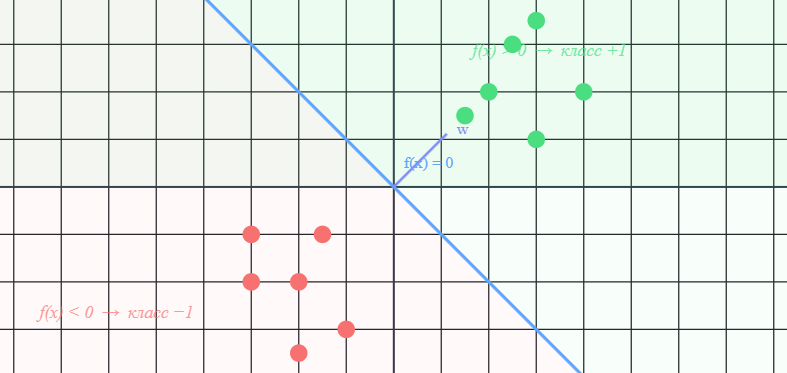

### Как работает классификация?

Для того, чтобы классифицировать объект мы вычисляем $f(x) = ⟨w, x⟩ + b$. Заметим, что этой формулой задаётся расстояние от точки до нашей разделяющей прямой (с учетом знака и масштаба):

$$⟨w, x⟩ = |w||x|·cos(θ)$$

$$r = \frac{f(x)}{‖w‖} = \frac{(⟨w, x⟩ + b)}{‖w‖}$$

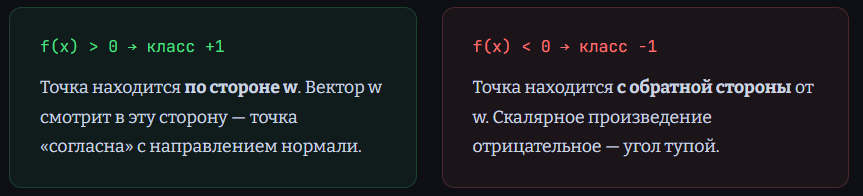

Тогда получается, что предсказание нашей модели есть ни что иное как:

$$\hat{y} = \text{sign}<w, x_i>$$

## Обучение модели

Для правильной классификации по сути нам надо минимизировать количество неправильных предсказаний:

$$\sum_{i} [y_i \neq \text{sign}\langle w, x_i \rangle] \longrightarrow \min_{w}$$

Упростим данное выражение:

$$\sum_{i} [y_i \langle w, x_i \rangle < 0] \longrightarrow \min_{w}$$


Вторая формула использует понятие отступа (margin) $M_i = y_i \langle w, x_i \rangle$.

- Если $M_i > 0$, то знаки истинного ответа и предсказания совпадают (классификация верна). Чем больше расстояние от $x_i$ до разделяющей плоскости, тем более уверен классификатоор.

- Если $M_i < 0$, то классификатор ошибся.



### Как обучать такую модель?

Нам нужно подобрать $w$ и $b$ так, чтобы прямая разделяла классы. Но $\text{sign(f(x))}$ — функция не дифференцируема, градиентный спуск напрямую не работает.

### Ошибка перцептрона

Давайте будем штрафовать только за неправильно классифицированные точки:

$$L_{perc}(w, b) = \max(0, -y_i(w^T x_i + b))$$



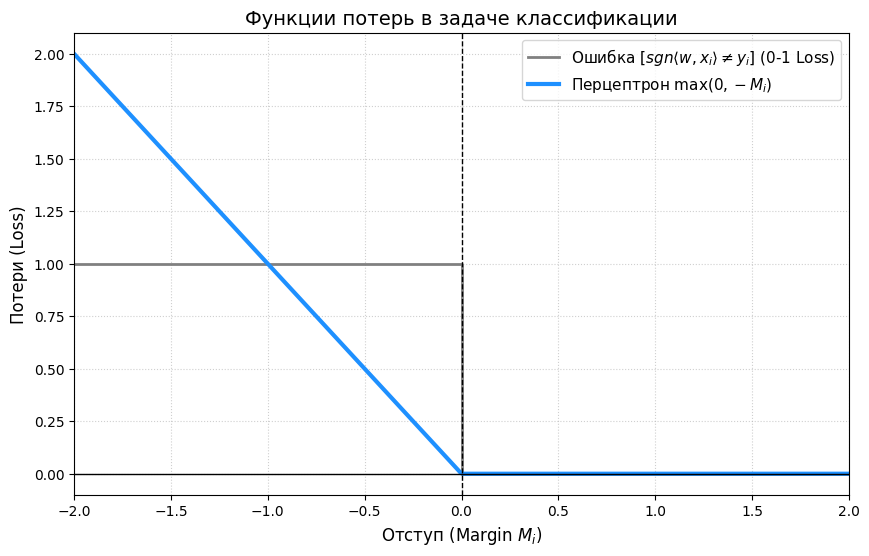

Как в таком случае обновляются веса? Давайте честно пропишем код обновления весов такой модели.

In [16]:
def score(X, w, b):
    """Предсказание модели: f(x) = w1*x1 + w2*x2 + b"""
    return X @ w + b

In [23]:
def perceptron_loss(X, y, w, b):
    """L = sum( max(0, -y * f(x)) )"""
    margins = -y * score(X, w, b)
    margins[margins < 0] = 0
    return margins.sum()

In [24]:
def perceptron_grad(X, y, w, b):
    """
    Градиент perceptron loss по w и b.
    Для ошибочной точки (y*f(x) <= 0):
        dL/dw = -y * x
        dL/db = -y
    Для правильной точки: градиент = 0.
    """
    margins = -y * score(X, w, b)
    mask = margins <= 0

    # Суммируем градиенты по всем ошибочным точкам
    grad_w = (-y[mask, None] * X[mask]).sum()
    grad_b = (-y[mask]).sum()

    n_errors = mask.sum()
    return grad_w, grad_b, n_errors

In [25]:
# Данные
data = np.array([
    [ 2.0,  2.0,  1],
    [ 3.0,  1.0,  1],
    [ 2.5,  3.0,  1],
    [ 3.5,  1.5,  1],
    [-2.0, -2.0, -1],
    [-1.0, -3.0, -1],
    [-3.0, -1.0, -1],
    [-2.5, -2.5, -1],
])

X = data[:, :2]
y = data[:, 2]

# Инициализация весов
np.random.seed(42)
w = np.array([0.1, -0.5])
b = 0.3

lr = 0.1
n_epochs = 5

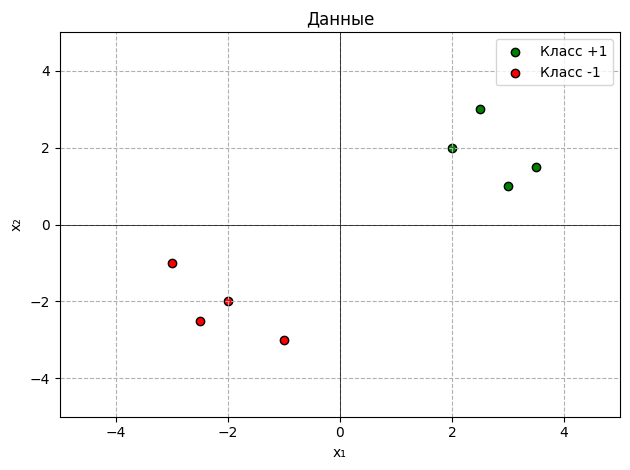

In [26]:
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Класс +1', edgecolors='k')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Класс -1', edgecolors='k')

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Данные')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

  Perceptron Loss — Градиентный спуск
  Начальные веса: w = [ 0.1 -0.5],  b = 0.30
  Learning rate: 0.1,  Epochs: 5

 Эпоха |     Loss | Ошибок |       w1 |       w2 |        b
------------------------------------------------------------
     1 |    6.150 |      1 |   0.1000 |  -0.5000 |   0.3000
     2 |    0.200 |      7 |   0.5000 |  -0.1000 |   0.4000
     3 |    0.000 |      8 |   3.6500 |   3.0500 |   0.5000
     4 |    0.000 |      8 |   7.2000 |   6.6000 |   0.5000
     5 |    0.000 |      8 |  10.7500 |  10.1500 |   0.5000

  Финальные веса: w = [14.3000, 13.7000],  b = 0.5000



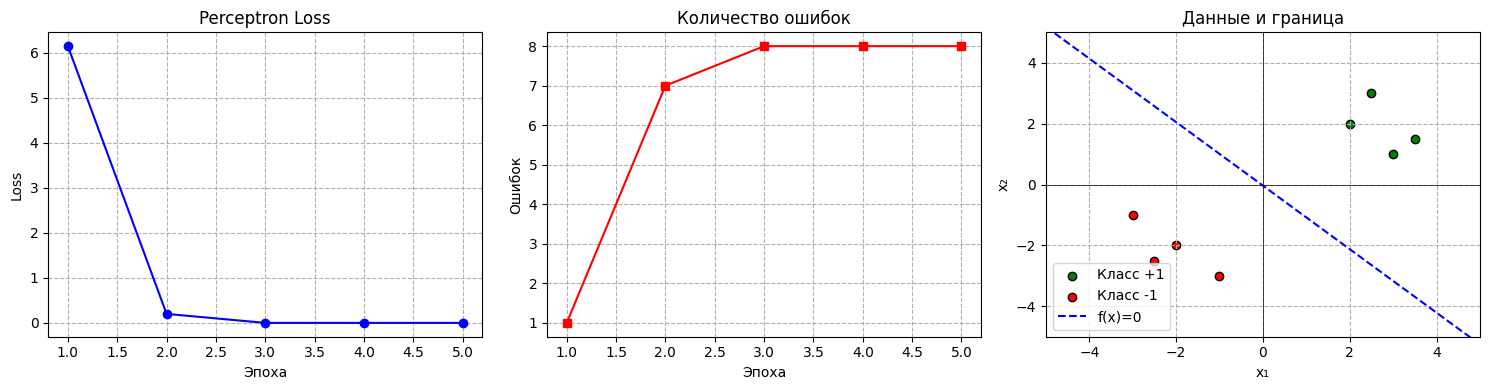

In [27]:
# Обучение
print("=" * 60)
print("  Perceptron Loss — Градиентный спуск")
print("=" * 60)
print(f"  Начальные веса: w = {w},  b = {b:.2f}")
print(f"  Learning rate: {lr},  Epochs: {n_epochs}")
print()
print(f"{'Эпоха':>6} | {'Loss':>8} | {'Ошибок':>6} | {'w1':>8} | {'w2':>8} | {'b':>8}")
print("-" * 60)

history_loss   = []
history_errors = []

for epoch in range(n_epochs):
    loss = perceptron_loss(X, y, w, b)
    grad_w, grad_b, n_errors = perceptron_grad(X, y, w, b)

    history_loss.append(loss)
    history_errors.append(n_errors)

    print(f"{epoch+1:>6} | {loss:>8.3f} | {n_errors:>6} | {w[0]:>8.4f} | {w[1]:>8.4f} | {b:>8.4f}")

    if n_errors == 0:
        print(f"\n  ✓ Все точки классифицированы верно. Останавливаемся.")
        break

    # Шаг градиентного спуска
    w = w - grad_w * lr
    b = b - grad_b * lr

print()
print(f"  Финальные веса: w = [{w[0]:.4f}, {w[1]:.4f}],  b = {b:.4f}")
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
ax = axes[0]
epochs_range = range(1, len(history_loss) + 1)
ax.plot(epochs_range, history_loss, color='blue', marker='o')
ax.set_title('Perceptron Loss')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Loss')
ax.grid(True, linestyle='--')

# Ошибки
ax = axes[1]
ax.plot(epochs_range, history_errors, color='red', marker='s')
ax.set_title('Количество ошибок')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Ошибок')
ax.grid(True, linestyle='--')
ax.yaxis.get_major_locator().set_params(integer=True)

# Визуализация данных и разделяющей плоскости
ax = axes[2]

ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Класс +1', edgecolors='k')
ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Класс -1', edgecolors='k')

x1_range = np.linspace(-5, 5, 100)
if abs(w[1]) > 1e-6:
    x2_boundary = -(w[0] * x1_range + b) / w[1]
    ax.plot(x1_range, x2_boundary, color='blue', linestyle='--', label='f(x)=0')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Данные и граница')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Главная проблема перцептрона — это отсутствие единственности решения.
Если данные линейно разделимы, существует бесконечное множество гиперплоскостей, которые дадут нулевую ошибку.

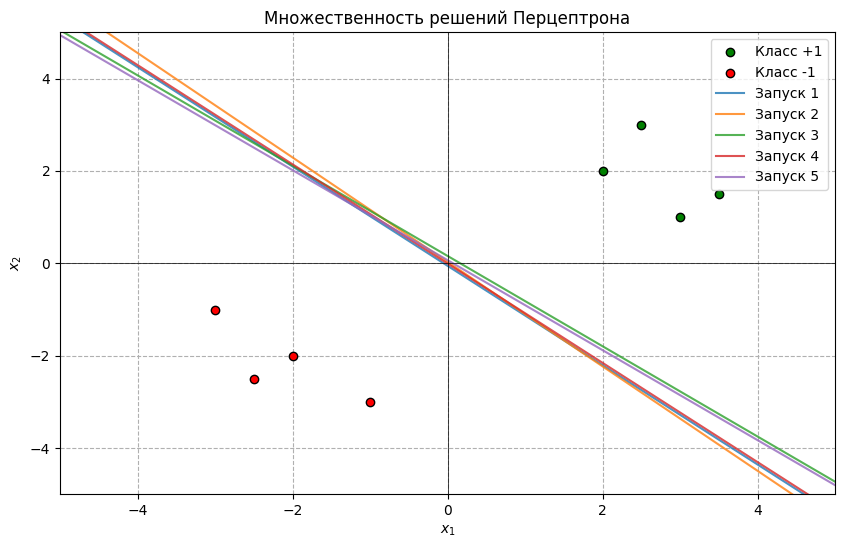

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))


plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Класс +1', edgecolors='k', zorder=5)
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Класс -1', edgecolors='k', zorder=5)

x1_range = np.linspace(-5, 5, 100)
n_runs = 5

for i in range(n_runs):
    # Новая случайная инициализация для каждого запуска
    np.random.seed(i)
    w_run = np.random.randn(2)
    b_run = np.random.randn()

    # Обучение
    for _ in range(n_epochs):
        grad_w, grad_b, n_errors = perceptron_grad(X, y, w_run, b_run)
        if n_errors == 0:
            break
        w_run = w_run - lr * grad_w
        b_run = b_run - lr * grad_b

    if abs(w_run[1]) > 1e-6:
        x2_boundary = -(w_run[0] * x1_range + b_run) / w_run[1]
        plt.plot(x1_range, x2_boundary, label=f'Запуск {i+1}', alpha=0.8)

plt.title('Множественность решений Перцептрона')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Заметим, что у данного метода есть один существенный недостаток -- мы можем провести множество разных разделяющих плоскостей. Как из них выбрать **лучшую**?

## SVM

Давайте вместо любой будем выбирать прямую с максимальным зазором (margin) — максимальным расстоянием до ближайших точек с каждой стороны.

По сути мы хотим ввести порог уверенности $M = 1$ и штрафуем всех, кто ниже этого порога:

$$L_{hinge}(x) = max(0, 1 − y·f(x)) = max(0, 1 − M)$$

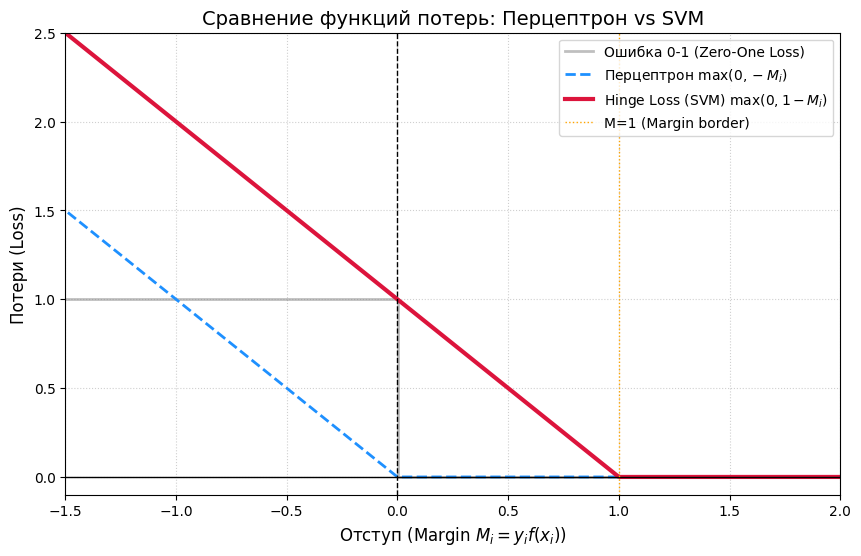

### Гемометрический смысл

Расстояние от точки до плоскости $x^Tw + b=0$ равно $\frac{|x^Tw + b |}{‖w‖}$. Если мы ввели наше ограничение и $y(x^Tw + b) \geq 1$, то расстояние до ближайших точек (тех, у которых $M = 1$) равно $\frac{1}{‖w‖}$. А расстояние между двумя полями — $\frac{2}{‖w‖}$.

То есть геометрический зазор между классами в модели SVM равен $\frac{2}{‖w‖}$.

Ближайшие точки называются **опорными веторами** (support vectors), а метод поиска разделяющей прямой с таким свойством -- support vector machine (SVM).

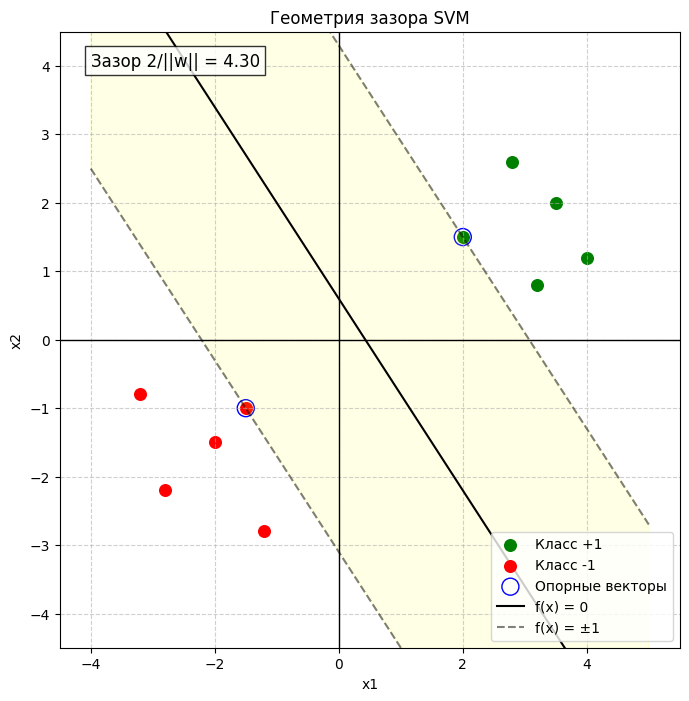

Веса (w): [0.37837838 0.27027027]
Смещение (b): -0.1622
Ширина зазора: 4.3012


In [29]:
# @title

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 1. Данные (линейно разделимые)
X_pos = np.array([[2.0, 1.5], [3.2, 0.8], [2.8, 2.6], [4.0, 1.2], [3.5, 2.0]])
X_neg = np.array([[-2.0, -1.5], [-1.2, -2.8], [-3.2, -0.8], [-2.8, -2.2], [-1.5, -1.0]])
X = np.vstack([X_pos, X_neg])
y = np.array([1]*5 + [-1]*5)

# 2. Обучение SVM (большой C обеспечивает Hard Margin)
model = SVC(kernel='linear', C=1e6)
model.fit(X, y)

w = model.coef_[0]
b = model.intercept_[0]
norm_w = np.linalg.norm(w)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(8, 8))

# Сетка и оси
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.grid(True, linestyle='--', alpha=0.6)

# Отрисовка точек
ax.scatter(X_pos[:, 0], X_pos[:, 1], color='green', label='Класс +1', s=70)
ax.scatter(X_neg[:, 0], X_neg[:, 1], color='red', label='Класс -1', s=70)

# Выделение опорных векторов
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
           s=150, facecolors='none', edgecolors='blue', label='Опорные векторы')

# Отрисовка разделяющей прямой и полей (margins)
x1_vals = np.linspace(-4, 5, 100)
# f(x) = w1*x1 + w2*x2 + b = 0  => x2 = -(w1*x1 + b) / w2
y_boundary = -(w[0] * x1_vals + b) / w[1]
y_plus = -(w[0] * x1_vals + b - 1) / w[1]   # Линия f(x) = 1
y_minus = -(w[0] * x1_vals + b + 1) / w[1]  # Линия f(x) = -1

ax.plot(x1_vals, y_boundary, 'k-', label='f(x) = 0')
ax.plot(x1_vals, y_plus, 'k--', alpha=0.5, label='f(x) = ±1')
ax.plot(x1_vals, y_minus, 'k--', alpha=0.5)

# Заливка области зазора
ax.fill_between(x1_vals, y_minus, y_plus, color='yellow', alpha=0.1)

# Аннотация зазора
# Расстояние между линиями f=1 и f=-1 равно 2/||w||
dist_text = f"Зазор 2/||w|| = {2/norm_w:.2f}"
ax.text(-4, 4, dist_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

ax.set_title('Геометрия зазора SVM')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_xlim(-4.5, 5.5)
ax.set_ylim(-4.5, 4.5)
ax.legend(loc='lower right')

plt.show()

# Краткий отчет
print(f"Веса (w): {w}")
print(f"Смещение (b): {b:.4f}")
print(f"Ширина зазора: {2/norm_w:.4f}")

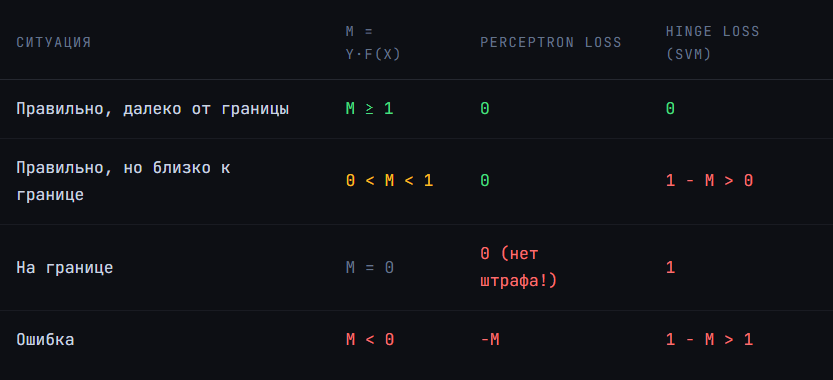

То есть наше условие минимизации записывается так:

$$\min_{w, b} \frac{1}{2} \|w\|^2 \quad \text{при условии } y_i (w^T x_i + b) \ge 1$$

Но на практике данные зашумлены и не разделимы линейно. Тогда вводятся дополнительнные переменные $\xi_i \ge 0$, которые позволяют точкам заходить внутрь зазора или даже на чужую территорию. Условие становится мягким:

$$y_i (w^T x_i + b) \ge 1 - \xi_i$$

а минимизируется при этом

$$L(w, b, \xi) = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{N} \xi_i$$

Параметр $C$ в данном случае управляет штрафом за ошибки классификации: чем больше $C$, тем менее терпима модель к нарушениям.

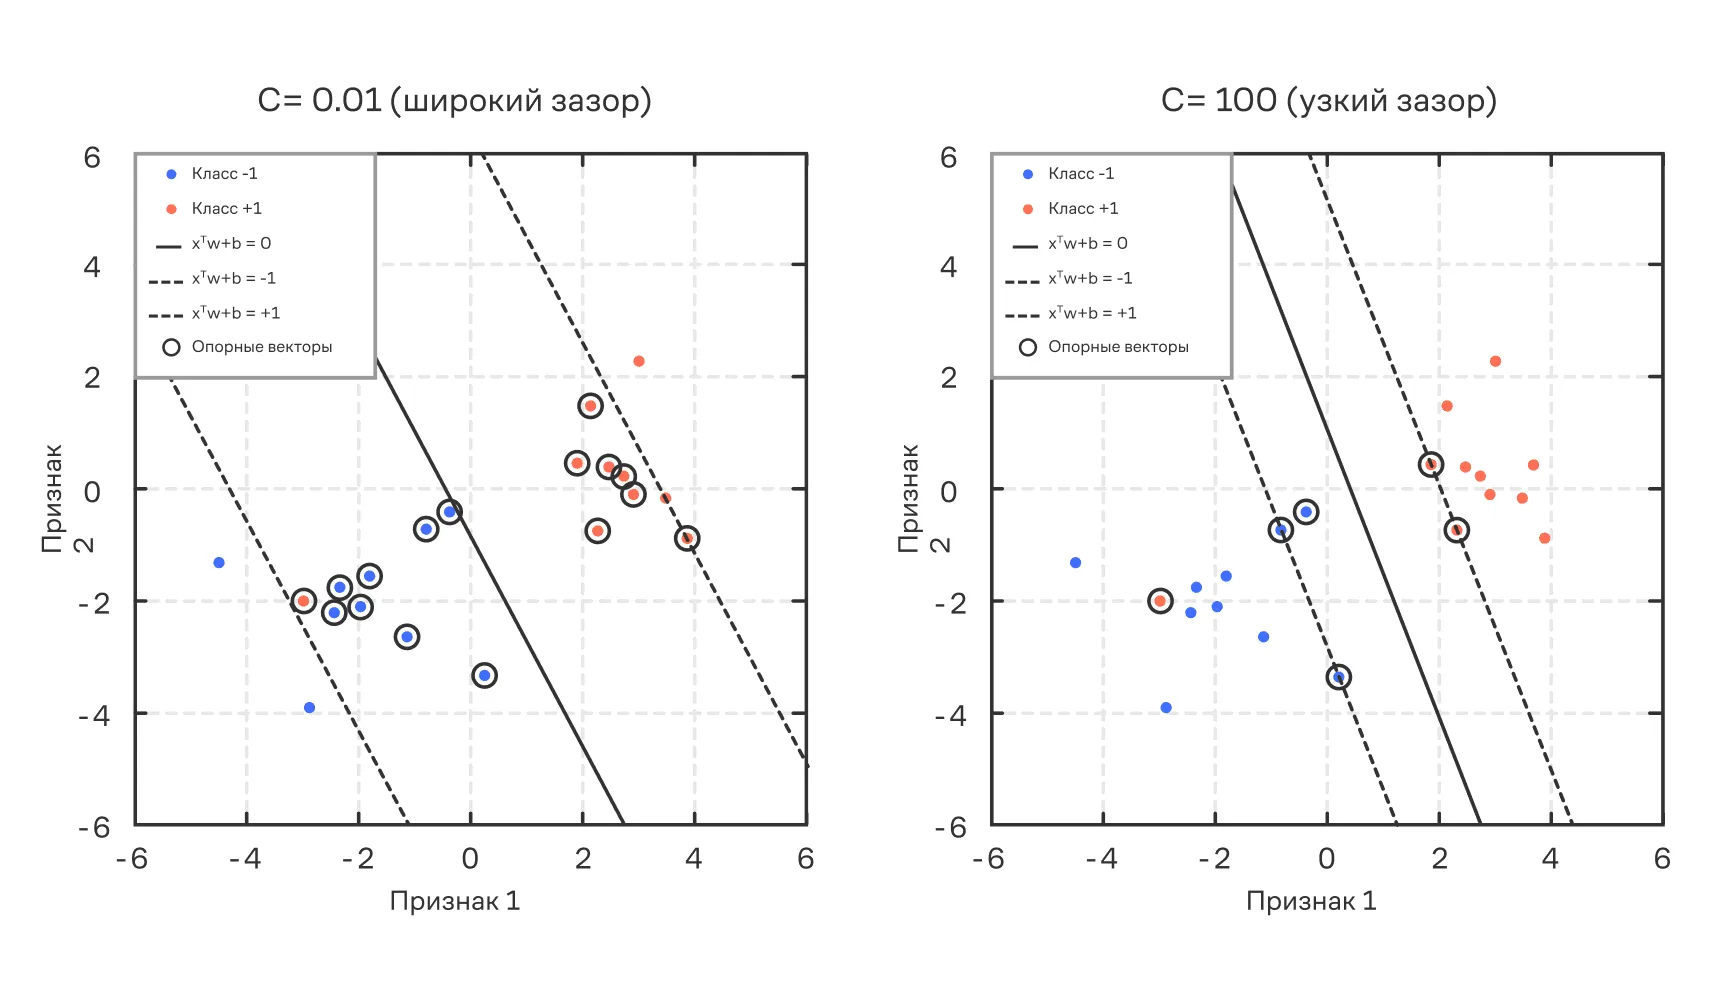

Давайте вспомним, что
$$y_i (w^T x_i + b) \ge 1 - \xi_i, \quad \text{где } \xi_i \ge 0$$

А тогда

$$\xi_i \ge 1 - y_i (w^T x_i + b)$$

Так как у нас есть еще условие $\xi_i \ge 0$, то минимально возможное значение для $\xi_i$, которое удовлетворяет обоим условиям, будет:$$\xi_i = \max(0, 1 - y_i (w^T x_i + b))$$

В итоге получаем

$$L = \underbrace{\frac{1}{2} \|w\|^2}_{\text{L2-регуляризация}} + C \sum_{i=1}^{n} \underbrace{\max(0, 1 - y_i (f(x_i)))}_{\text{Hinge Loss}}$$

Давайте напишем код и градиент Hinge loss.

In [30]:
np.random.seed(42)
X_raw = np.array([
    [ 2.0,  1.5], [ 3.2,  0.8], [ 2.8,  2.6], [ 4.0,  1.2], [ 3.5,  2.0],
    [-2.0, -1.5], [-1.2, -2.8], [-3.2, -0.8], [-2.8, -2.2], [-1.5, -1.0],
])
y = np.array([1, 1, 1, 1, 1, -1, -1, -1, -1, -1], dtype=float)

X = np.hstack([X_raw, np.ones((len(X_raw), 1))])
n, d = X.shape


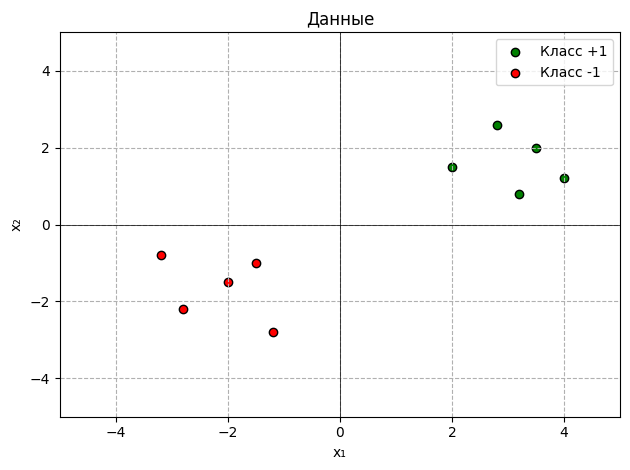

In [31]:
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='Класс +1', edgecolors='k')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Класс -1', edgecolors='k')

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Данные')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
def hinge_loss(w, X, y, C):
    """
    L(w) = 0.5 * ||w_feat||^2 + C * mean(max(0, 1 - yi<w, xi>))

    """
    scores = X @ w + b
    margins = y * scores
    margins = -margins + 1
    margins[margins < 0] = 0
    hinge_mean = np.mean(margins)
    reg = 0.5 * np.dot(w[:2], w[:2])
    return reg + C * hinge_mean

def hinge_grad(w, X, y, C):
    """
    grad = [w_feat, 0] + C * mean(grad_hinge)
    """
    n, d = X.shape
    scores = X @ w + b
    margins = # YOUR CODE IS HERE
    mask = # YOUR CODE IS HERE

    # Градиент среднего: сумма / n
    grad_hinge = # YOUR CODE IS HERE
    grad_reg = # YOUR CODE IS HERE

    return grad_reg + C * grad_hinge

SyntaxError: invalid syntax (1698655674.py, line 6)

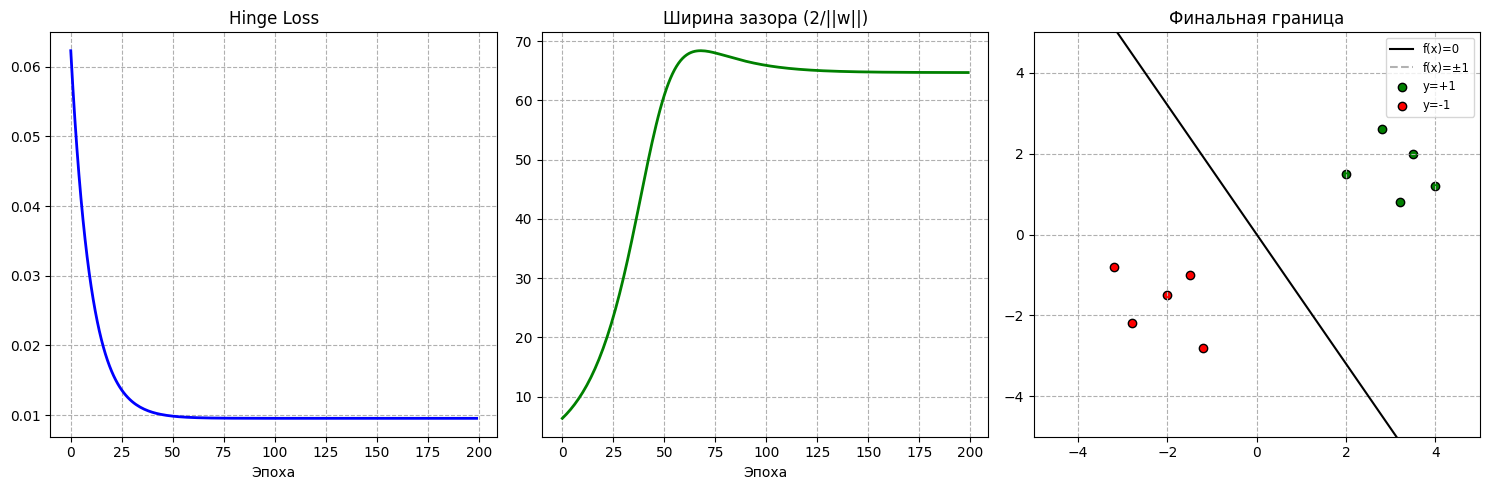

Финальные веса: w1=0.0262, w2=0.0164, b=0.0000
Ширина зазора: 64.7127


In [ ]:
C, lr, n_epochs = 0.01, 0.05, 200
w = np.array([0.1, -0.3, 0.0])

history = {'loss': [], 'margin': []}

for epoch in range(n_epochs):
    loss = # YOUR CODE IS HERE
    grad = # YOUR CODE IS HERE

    # Зазор считаем только по фичам (w1, w2)
    w_feat_norm = np.linalg.norm(w[:2])
    margin = 2 / w_feat_norm if w_feat_norm > 1e-8 else 0

    history['loss'].append(loss)
    history['margin'].append(margin)

    w = w - lr * grad

plt.figure(figsize=(15, 5))

# Hinge Loss
plt.subplot(1, 3, 1)
plt.plot(history['loss'], color='blue', lw=2)
plt.title('Hinge Loss')
plt.xlabel('Эпоха')
plt.grid(True, linestyle='--')

# Размер зазора
plt.subplot(1, 3, 2)
plt.plot(history['margin'], color='green', lw=2)
plt.title('Ширина зазора (2/||w||)')
plt.xlabel('Эпоха')
plt.grid(True, linestyle='--')

# Финальный результат
plt.subplot(1, 3, 3)
w1, w2, b = w
xx = np.linspace(-5, 5, 100)
yy = -(w1 * xx + b) / w2
yy_p = -(w1 * xx + b - 1) / w2
yy_m = -(w1 * xx + b + 1) / w2

plt.plot(xx, yy, 'k-', label='f(x)=0')
plt.plot(xx, yy_p, 'k--', alpha=0.3, label='f(x)=±1')
plt.plot(xx, yy_m, 'k--', alpha=0.3)

plt.scatter(X_raw[y==1, 0], X_raw[y==1, 1], c='green', label='y=+1', edgecolors='k')
plt.scatter(X_raw[y==-1, 0], X_raw[y==-1, 1], c='red', label='y=-1', edgecolors='k')

plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.title('Финальная граница')
plt.legend(fontsize='small')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

print(f"Финальные веса: w1={w[0]:.4f}, w2={w[1]:.4f}, b={w[2]:.4f}")
print(f"Ширина зазора: {2/np.linalg.norm(w[:2]):.4f}")

### SVM from Sklearn

Аналогично мы можем просто воспользоваться библиотекой `sklearn`.

In [ ]:
from sklearn import svm

clf = svm.SVC(kernel='linear', C=C/len(y))
clf.fit(X_raw, y)

SVC(C=0.001, kernel='linear')

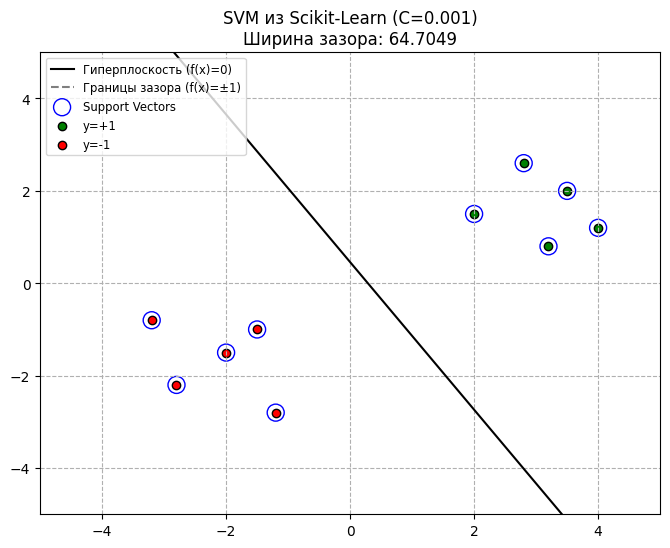

Веса (w): [0.0262 0.0164]
Смещение (b): [-0.00753]
Ширина зазора: 64.7049


In [ ]:
w = clf.coef_[0]        # Веса w1, w2
b = clf.intercept_      # Свободный член (bias)
w_norm = np.linalg.norm(w)
margin = 2 / w_norm

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(8, 6))

xx = np.linspace(-5, 5, 100)
yy = -(w[0] * xx + b) / w[1]
yy_up = yy + 1/w[1]
yy_down = yy - 1/w[1]

plt.plot(xx, yy, 'k-', label='Гиперплоскость (f(x)=0)')
plt.plot(xx, yy_up, 'k--', alpha=0.5, label='Границы зазора (f(x)=±1)')
plt.plot(xx, yy_down, 'k--', alpha=0.5)

# Подсветка опорных векторов (Support Vectors)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150,
            facecolors='none', edgecolors='blue', label='Support Vectors')

# Отрисовка точек
plt.scatter(X_raw[y==1, 0], X_raw[y==1, 1], c='green', edgecolors='k', label='y=+1')
plt.scatter(X_raw[y==-1, 0], X_raw[y==-1, 1], c='red', edgecolors='k', label='y=-1')

plt.title(f"SVM из Scikit-Learn (C={clf.C})\nШирина зазора: {margin:.4f}")
plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, linestyle='--')
plt.show()

print(f"Веса (w): {w}")
print(f"Смещение (b): {b}")
print(f"Ширина зазора: {margin:.4f}")

Давайте немного "пошевелим" $C$ и посмотрим, как меняется ширина зазора.

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from ipywidgets import interact, FloatLogSlider

def plot_svm_interactive(C):
    # Обучаем модель с текущим C
    clf = svm.SVC(kernel='linear', C=C).fit(X_raw, y)

    w = clf.coef_[0]
    b = clf.intercept_[0]
    w_norm = np.linalg.norm(w)
    margin = 2 / w_norm

    plt.figure(figsize=(8, 6))

    xx = np.linspace(-5, 5, 100)
    yy = -(w[0] * xx + b) / w[1]

    yy_up = yy + 1/w[1]
    yy_down = yy - 1/w[1]

    plt.plot(xx, yy, 'k-', label='f(x)=0')
    plt.plot(xx, yy_up, 'k--', alpha=0.3, label='f(x)=±1')
    plt.plot(xx, yy_down, 'k--', alpha=0.3)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150,
                facecolors='none', edgecolors='blue', label='Support Vectors')

    plt.scatter(X_raw[y==1, 0], X_raw[y==1, 1], c='green', edgecolors='k', label='y=+1')
    plt.scatter(X_raw[y==-1, 0], X_raw[y==-1, 1], c='red', edgecolors='k', label='y=-1')

    plt.title(f"Влияние C на зазор SVM\nC = {C:.4f}, Ширина зазора = {margin:.4f}")
    plt.xlim(-5, 5); plt.ylim(-5, 5)
    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True, linestyle='--')
    plt.show()

interact(plot_svm_interactive,
         C=FloatLogSlider(value=1.0, base=10, min=-3, max=3, step=0.1, description='C'))

interactive(children=(FloatLogSlider(value=1.0, description='C', max=3.0, min=-3.0), Output()), _dom_classes=(…

<function __main__.plot_svm_interactive(C)>

## Немного математики для всех желающих

### Метод Лагранжа

Пусть нужно найти максимум (или минимум) функции $f(x, y)$ при условии, что точка лежит на кривой $g(x, y) = 0$.

Геометрический смысл данной постановки следующий: в точке экстремума линии уровня функции f и кривая ограничения g = 0 должны быть **касательными**.

Это также выражается через коллинеарность градиентов:

$$\nabla f = \lambda \nabla g$$

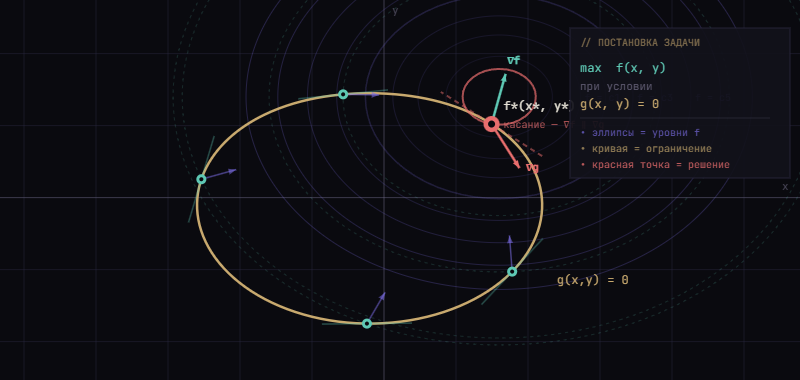

Введём функцию Лагранжа, которая объединяет задачу оптимизации и ограничение:

$$\mathcal{L}(x,y, \lambda) = f(x, y) - \lambda g(x, y)$$

Чтобы найти критические точки, нужно взять частные производные по всем переменным и приравнять их к нулю:

1. $\frac{\partial L}{\partial x} = 0$

2. $\frac{\partial L}{\partial y} = 0$

3. $\frac{\partial L}{\partial \lambda} = 0$ (это просто возвращает нас к исходному ограничению $g(x, y) = 0$)

### Пример

#### Расстояние до начала координат

Найдем точку на прямой $x + y = 1$, которая ближе всего к началу координат $(0, 0)$.

1. **Целевая функция**: $f(x, y) = x^2 + y^2$

2. **Ограничение:** $g(x, y) = x + y - 1 = 0$

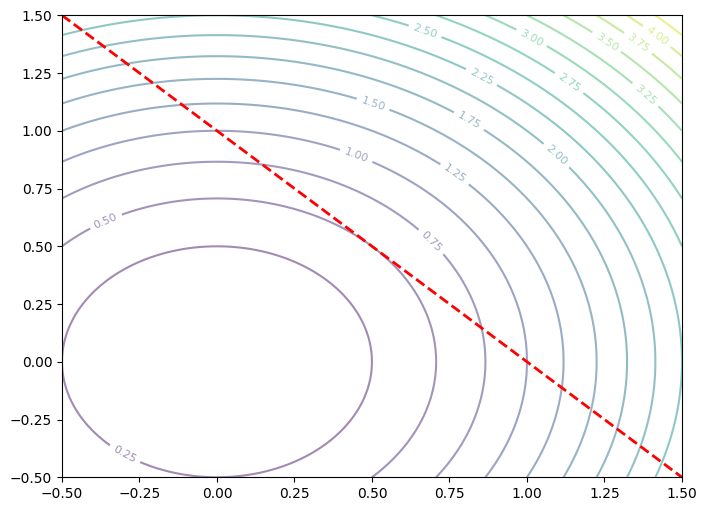

In [ ]:
# @title
x_range = np.linspace(-0.5, 1.5, 100)
y_range = np.linspace(-0.5, 1.5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

plt.figure(figsize=(8, 6))
# Линии уровня функции
cp = plt.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.5)
plt.clabel(cp, inline=True, fontsize=8)

# Линия ограничения x + y = 1 => y = 1 - x
plt.plot(x_range, 1 - x_range, 'r--', label='Constraint: x + y = 1', linewidth=2)

plt.show()

Составляем Лагранжиан:

$$L = x^2 + y^2 - \lambda(x + y - 1)$$

1. $L_x = 2x - \lambda = 0 \Rightarrow \lambda = 2x$

2. $L_y = 2y - \lambda = 0 \Rightarrow \lambda = 2y$

3. $L_\lambda = x + y - 1 = 0$

Из первых двух уравнений: $2x = 2y \Rightarrow x = y$.

Подставляем в ограничение: $x + x = 1 \Rightarrow x = 0.5, y = 0.5$.


Ответ: **x = 0.5, y = 0.5**

Для оптимизации функции с ограничением можно использовать библиотеку `scipy` и функцию `minimize`.

In [ ]:
# 1. Определяем целевую функцию f(x, y) = x^2 + y^2
def objective(P):
    x, y = P
    return x**2 + y**2

# 2. Определяем ограничение g(x, y) = x + y - 1 = 0
def constraint(P):
    x, y = P
    return x + y - 1

In [ ]:
from scipy.optimize import minimize

# Начальное приближение
x0 = [10, 10]

# Формируем структуру ограничения для scipy
con = {'type': 'eq', 'fun': constraint}

# Решаем
sol = minimize(objective, x0, constraints=con)

print(f"Оптимальное x: {sol.x[0]:.2f}")
print(f"Оптимальное y: {sol.x[1]:.2f}")
print(f"Минимальное значение f: {sol.fun:.2f}")

Оптимальное x: 0.50
Оптимальное y: 0.50
Минимальное значение f: 0.50


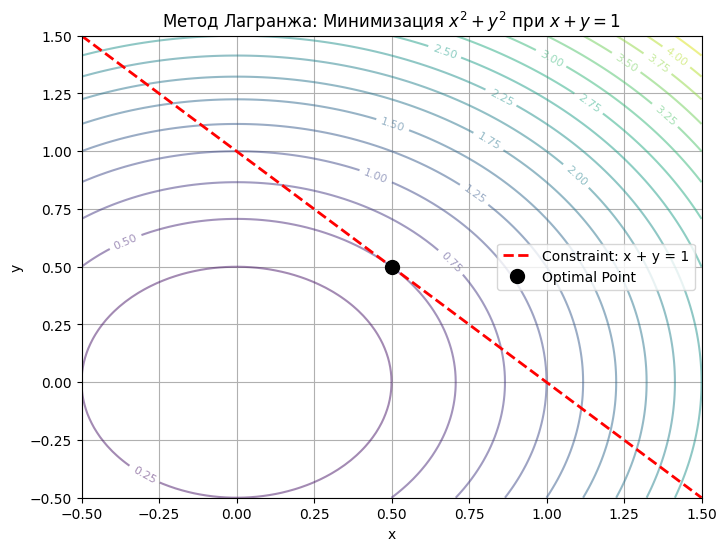

In [ ]:
# @title
x_range = np.linspace(-0.5, 1.5, 100)
y_range = np.linspace(-0.5, 1.5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

plt.figure(figsize=(8, 6))
# Линии уровня функции
cp = plt.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.5)
plt.clabel(cp, inline=True, fontsize=8)

# Линия ограничения x + y = 1 => y = 1 - x
plt.plot(x_range, 1 - x_range, 'r--', label='Constraint: x + y = 1', linewidth=2)

# Точка решения
plt.plot(sol.x[0], sol.x[1], 'ko', markersize=10, label='Optimal Point')

plt.title('Метод Лагранжа: Минимизация $x^2 + y^2$ при $x+y=1$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Заметим, что наше теоретическое решение сошлось с практическим :)

### А если точка на параболе?

Хотим решить предыдущую задачу, но с условием, что точка лежит на параболе $y = x^2 - 1$.

1. **Целевая функция**: $f(x, y) = x^2 + y^2$

2. **Ограничение:** $g(x, y) = y - x^2 + 1 = 0$

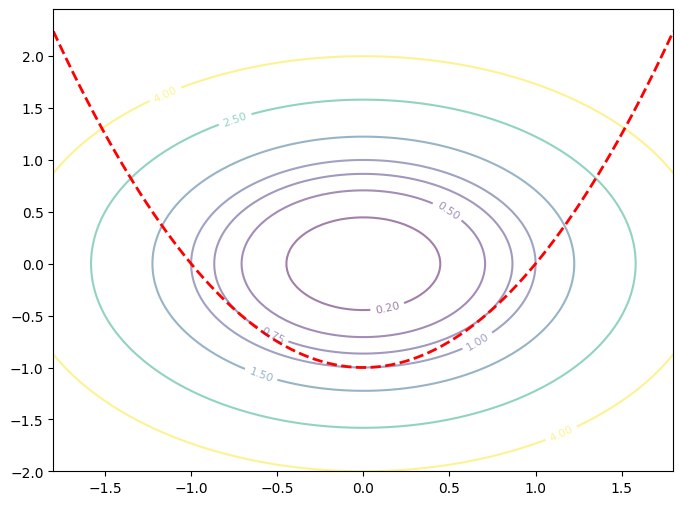

In [ ]:
# @title
x_range = np.linspace(-1.8, 1.8, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

plt.figure(figsize=(8, 6))
# Линии уровня функции
cp = plt.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
plt.clabel(cp, inline=True, fontsize=8)

# Линия ограничения
levels = [0.2, 0.5, 0.75, 1.0, 1.5, 2.5, 4.0]
plt.plot(x_range, x_range**2 - 1, 'r--', label='Constraint: x + y = 1', linewidth=2)

plt.show()

Выпишем Лагранжиан:

$$L(x, y, \lambda) = x^2 + y^2 - \lambda(y - x^2 + 1)$$

Составим систему уравнений:

1. $\frac{\partial L}{\partial x} = 2x + 2\lambda x = 2x(1 + \lambda) = 0$

2. $\frac{\partial L}{\partial y} = 2y - \lambda = 0 \Rightarrow \lambda = 2y$

3. $y - x^2 + 1 = 0$



Из первого уравнения получаем что либо $x=0$, либо $\lambda = -1$.

1. $x = 0$:

- Из ограничения $y = 0^2 - 1 = -1$. Точка $(0, -1)$.

- Квадрат расстояния $f = 1$.

2. $\lambda = -1$:

Подставляем во второе уравнение: $2y = -1 \Rightarrow y = -0.5$.

- Из ограничения: $-0.5 = x^2 - 1 \Rightarrow x^2 = 0.5 \Rightarrow x = \pm\sqrt{0.5}$.

- Квадрат расстояния $f = 0.5 + 0.25 = 0.75$.

**Ответ:** $(\pm\sqrt{0.5}, -0.5)$

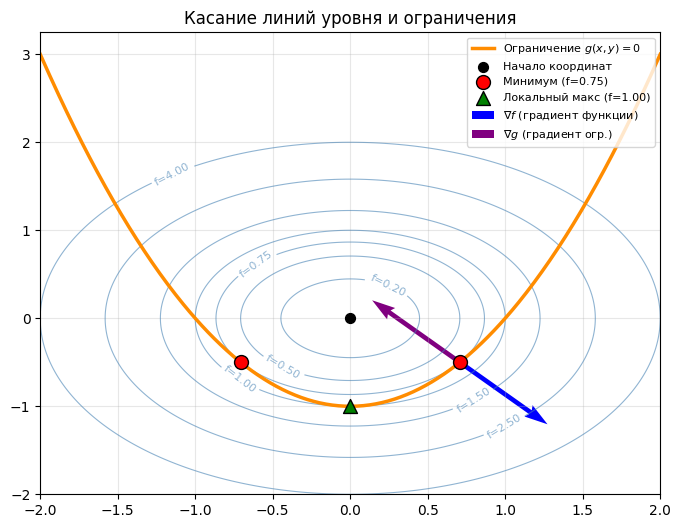

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# --- Параметры задачи ---
x_min = np.sqrt(0.5)
y_min = -0.5
dist_min_sq = x_min**2 + y_min**2

x_local = 0.0
y_local = -1.0
dist_local_sq = 1.0


plt.figure(figsize=(8, 6))

# Сетка для линий уровня f(x,y) = x^2 + y^2
xg = np.linspace(-2.0, 2.0, 400)
yg = np.linspace(-2.0, 2.0, 400)
X, Y = np.meshgrid(xg, yg)
F = X**2 + Y**2

# Линии уровня
levels = [0.2, 0.5, 0.75, 1.0, 1.5, 2.5, 4.0]
cs = plt.contour(X, Y, F, levels=levels, colors="steelblue", linewidths=0.8, alpha=0.6)
plt.clabel(cs, fmt="f=%.2f", fontsize=8, inline=True)

# Ограничения (парабола)
plt.plot(xg, xg**2 - 1, color="darkorange", linewidth=2.5, label="Ограничение $g(x,y)=0$")

# Точки решения
plt.scatter([0], [0], color="black", s=50, zorder=5, label="Начало координат")
plt.scatter([x_min, -x_min], [y_min, y_min], color="red", s=100, edgecolors='black',
           zorder=6, label=f"Минимум (f={dist_min_sq:.2f})")
plt.scatter([x_local], [y_local], color="green", s=100, marker="^", edgecolors='black',
           zorder=6, label=f"Локальный макс (f={dist_local_sq:.2f})")

# Векторы градиентов в точке минимума (для демонстрации параллельности)
# grad f = (2x, 2y), grad g = (-2x, 1)
gx, gy = 2*x_min, 2*y_min
plt.quiver(x_min, y_min, gx, gy, color='blue', scale=10, label='$\\nabla f$ (градиент функции)')
plt.quiver(x_min, y_min, -2*x_min, 1, color='purple', scale=10, label='$\\nabla g$ (градиент огр.)')

plt.xlim(-2, 2); ax.set_ylim(-1.3, 2)
plt.legend(fontsize=8, loc="upper right")
plt.grid(True, alpha=0.3)
plt.title("Касание линий уровня и ограничения")
plt.show()

### Лагранж и двойственная задача

Мы с вами кратко разобрались с функцией Лагранжа. Давайте теперь применим её в нашей задаче оптимизации.

Вспомним, что мы хотим минимизировать $\frac{1}{2} \|w\|^2$ при условии, что все точки лежат правильно:

$$y_i (w^T x_i + b) \ge 1, \quad i = 1, \dots, n$$

Запишем функцию Лагранжа:

$$L(w, b, \alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^{n} \alpha_i \left[ y_i(w^Tx_i + b) - 1 \right]$$Здесь $\alpha_i \ge 0$ — это множители Лагранжа.  

Возьмем частные производные и приравняем их к нулю:

1. По $w$:

$$\frac{\partial L}{\partial w} = w - \sum_{i=1}^{n} \alpha_i y_i x_i = 0 \quad \implies \quad \mathbf{w = \sum_{i=1}^{n} \alpha_i y_i x_i}$$

**Важно**:  оптимальный вектор весов $w$ — это линейная комбинация объектов обучающей выборки.

2. По $b$:

$$\frac{\partial L}{\partial b} = \sum_{i=1}^{n} \alpha_i y_i = 0$$



Подставим $w$ в $\frac{1}{2}\|w\|^2$, чтобы получить задачу оптимизации только по $\alpha$:

$$\frac{1}{2} \left( \sum \alpha_i y_i x_i \right) \cdot \left( \sum \alpha_j y_j x_j \right) = \frac{1}{2} \sum \sum \alpha_i \alpha_j y_i y_j (x_i \cdot x_j)$$



После сокращений получается целевая функция двойственной задачи:

$$W(\alpha) = \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j (\mathbf{x_i^T x_j})$$


Ее нужно максимизировать по $\alpha$ при условиях:

- $\alpha_i \ge 0$ (и $\alpha_i \le C$ для мягкого зазора).

- $\sum \alpha_i y_i = 0$.

Тогда разделяющая плоскость выглядит как

$$f(x) = w^T x + b$$

$$f(x) = \left( \sum_{i=1}^{n} \alpha_i y_i x_i \right)^T x + b$$

$$f(x) = \sum_{i=1}^{n} \alpha_i y_i (x_i^T x) + b$$

А предсказание:

$$\hat{y}(x) = sign\left(\sum_{i=1}^{m} \alpha_i y_i x_i^T x_j + b\right)$$

Большинство $\alpha_i$ обнуляется, и только несколько объектов $x_i$,
у которых $\alpha_i > 0$, влияют на решение --- они и являются опорными векторами.

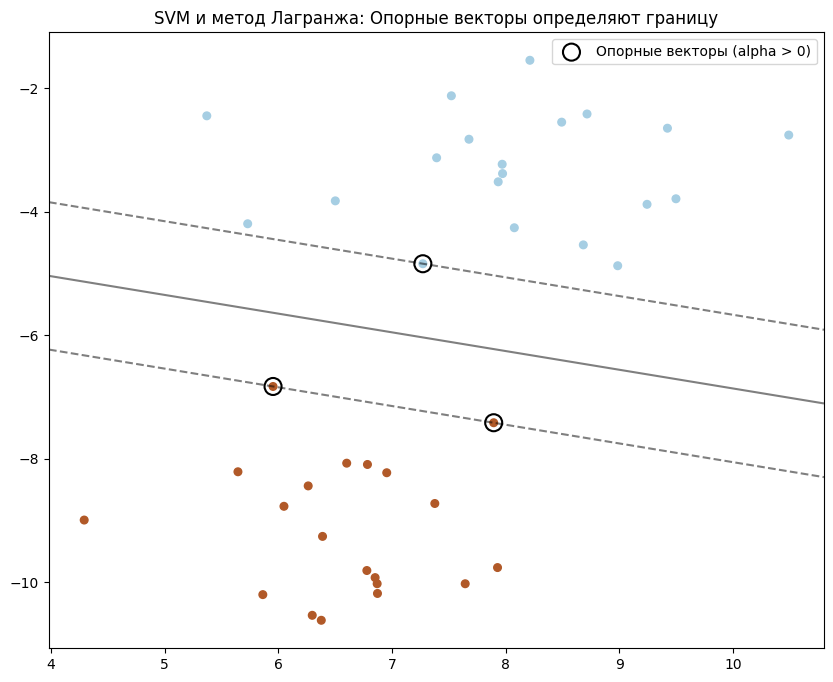

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

# 1. Генерируем данные
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# 2. Обучаем SVM с линейным ядром
clf = svm.SVC(kernel='linear', C=1000)
clf.fit(X, y)

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# 3. Рисуем разделяющую плоскость и зазоры
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Линии уровня: g(x) = -1, 0, 1 (аналог наших ограничений)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# 4. Выделяем опорные векторы (те, у кого alpha > 0)
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150,
           linewidth=1.5, facecolors='none', edgecolors='k',
           label='Опорные векторы (alpha > 0)')

plt.title("SVM и метод Лагранжа: Опорные векторы определяют границу")
plt.legend()
plt.show()

### Зачем все это было?

Здесь возникает ключевое наблюдение: вся задача выражена только через скалярные произведения $x_i^T x_j$.

Это поможет нам применять kernel-trick, который мы разберём ниже.



## Kernel-trick

Если данные линейно неразделимы в исходном пространстве $\mathbb{R}^n$, мы можем отобразить их в пространство более высокой размерности $\mathcal{H}$ с помощью функции $\phi(x)$.

Если мы возьмем исходную формулировку, то разделяющая плоскость будет задаваться уравнением:

$$f(x) = w^T \phi(x) + b$$

Если мы захотим перейти к полиному 4 степени из пространства фичей 2D, то у нас получится 15D пространство.

1. Константа: $1$
2. 1-я степень: $x_1, x_2$
3. 2-я степень: $x_1^2, x_2^2, x_1x_2$
4. 3-я степень: $x_1^3, x_2^3, x_1^2x_2, x_1x_2^2$
5. 4-я степень: $x_1^4, x_2^4, x_1^3x_2, x_1^2x_2^2, x_1x_2^3$

Если же на входе будет больше признаков, то количество новых фичей будет слишком быстро расти и хранить эти данные для оптимизации будет довольно затруднительо.

Тут на помощь нам приходит та самая двойственная формулировка, которая говорит, что нам не надо знать отдельно $x$ (и соответственно все его производые фичи), а надо знать только $\mathbf{x_i^T x_j}$. Если у нас размерность фичи была $n$, то всего операций O(n) и не зависит от степени полинома. В случае, если же мы честно считаем все степени, то размерность сложность становится O(D), где $D \gg n$.

В случае, когда мы работаем с датасетом с N примерами, то общая сложность будет $O(N^2n)$.

Вернемся к SVM. Мы знаем, что мы вместо исходной задачи мы можем максимизировать

$$W(\alpha) = \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j (\mathbf{x_i^T x_j})$$

При этом

$$\mathbf{w} = \sum \alpha_i y_i x_i$$

Разделяющая плоскость:

$$f(x) = \sum_{i=1}^{n} \alpha_i y_i (x_i^T x) + b$$

Для того чтобы предсказать класс новой точки $x$, нам не нужно знать $w$. Нам нужно только уметь считать скалярное произведение между новой точкой и опорными векторами.






Поскольку мы выяснили, что нам нужно только скалярное произведение, мы можем при переходе в более сложное пространство вычислять не $\phi(x)$, а сразу функцию $K(x_i, x)$.

В этом случае разделяющая плоскость выглядит как

$$f(x) = \sum \alpha_i y_i \mathbf{K(x_i, x)} + b$$

#### Сравнение скорости работы стандартного алгоритма SVM и через двойственную задачу

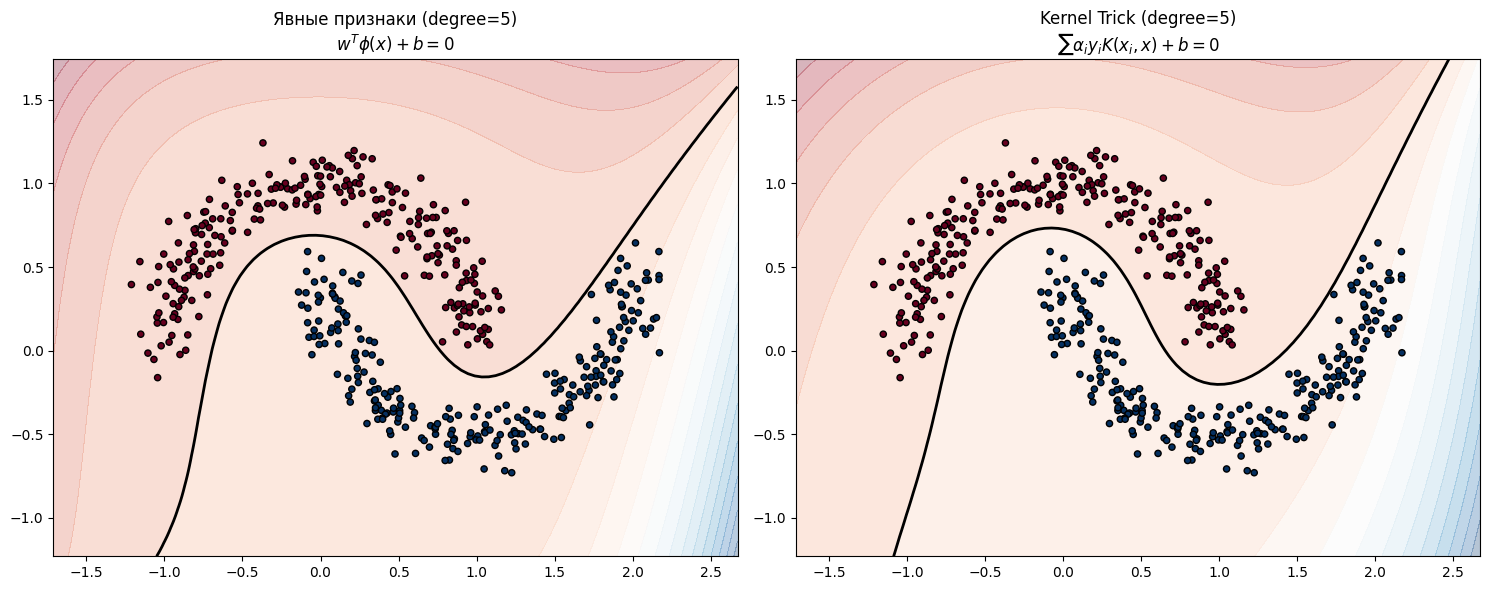

Размерность X (исходная): (500, 2)
Размерность X_poly (явная): (500, 21)
------------------------------
Время (Explicit): 0.0020 сек
Время (Kernel Trick): 0.0020 сек
Kernel Trick быстрее в 1.0 раз


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

# X - это 500 точек, каждая имеет 2 координаты (x1, x2)
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)


k = 5  # Степень полинома

# Явное создание признаков
poly = PolynomialFeatures(degree=k)
X_poly = poly.fit_transform(X)

start_ext = time.time()

# Обучаем линейный SVM
clf_explicit = svm.SVC(kernel='linear').fit(X_poly, y)
time_explicit = time.time() - start_ext

# Kernel Trick
start_ker = time.time()
# Обучаем SVM с полиномиальным ядром на исходных 2D признаках
clf_kernel = svm.SVC(kernel='poly', degree=k, coef0=1).fit(X, y)
time_kernel = time.time() - start_ker

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_boundaries(clf, X, y, ax, title, is_explicit=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    if is_explicit:
        grid_points = poly.transform(grid_points)

    Z = clf.decision_function(grid_points)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', s=20)
    ax.set_title(title)

plot_boundaries(clf_explicit, X, y, axes[0],
                fr"Явные признаки (degree={k})" + "\n" + r"$w^T \phi(x) + b = 0$",
                is_explicit=True)

plot_boundaries(clf_kernel, X, y, axes[1],
                fr"Kernel Trick (degree={k})" + "\n" + r"$\sum \alpha_i y_i K(x_i, x) + b = 0$")

plt.tight_layout()
plt.show()

print(f"Размерность X (исходная): {X.shape}")
print(f"Размерность X_poly (явная): {X_poly.shape}")
print("-" * 30)
print(f"Время (Explicit): {time_explicit:.4f} сек")
print(f"Время (Kernel Trick): {time_kernel:.4f} сек")
print(f"Kernel Trick быстрее в {time_explicit / time_kernel:.1f} раз")

Более наглядный пример с большим количеством признаков.

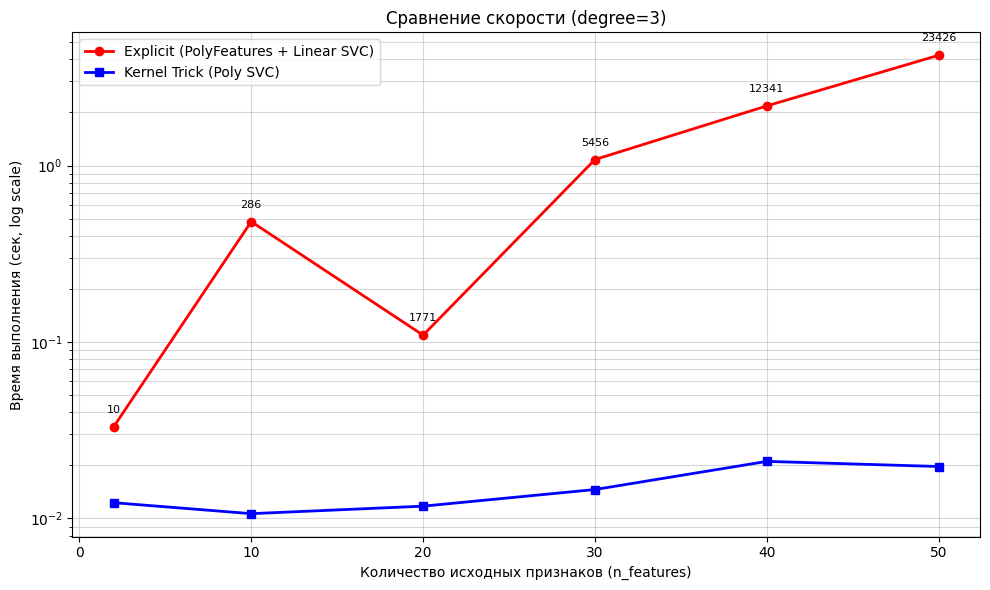

In [ ]:
# @title
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures

n_samples = 500
degree = 3
features_range = [2, 10, 20, 30, 40, 50]

time_explicit = []
time_kernel = []
n_poly_features = []

for n_feats in features_range:
    X = np.random.randn(n_samples, n_feats)
    y = np.random.randint(0, 2, n_samples)

    start = time.time()
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    n_poly_features.append(X_poly.shape[1])

    clf_linear = SVC(kernel='linear')
    clf_linear.fit(X_poly, y)
    time_explicit.append(time.time() - start)

    # 2. Kernel Trick
    start = time.time()
    clf_poly = SVC(kernel='poly', degree=degree, coef0=1)
    clf_poly.fit(X, y)
    time_kernel.append(time.time() - start)

plt.figure(figsize=(10, 6))

plt.plot(features_range, time_explicit, 'o-', label='Explicit (PolyFeatures + Linear SVC)', color='red', lw=2)
plt.plot(features_range, time_kernel, 's-', label='Kernel Trick (Poly SVC)', color='blue', lw=2)

for i, txt in enumerate(n_poly_features):
    plt.annotate(f"{txt}", (features_range[i], time_explicit[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.yscale('log') # Логарифмическая шкала, иначе очень большая разница
plt.title(f'Сравнение скорости (degree={degree})')
plt.xlabel('Количество исходных признаков (n_features)')
plt.ylabel('Время выполнения (сек, log scale)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### Примеры работы с разными ядрами

Давайте рассмотрим ещё примеры применения различных kernels для решения задачи.

Для этого сначала введём ещё RBF-kernel:

$$K(x_i, x_j) = \exp\left( -\gamma \|x_i - x_j\|^2 \right)$$

Данное ядро неявно вычисляет скалярное произведение в пространстве, где признаками являются все возможные степени и комбинации переменных до бесконечности. То есть в явном виде мы бы даже не смогли его использовать.

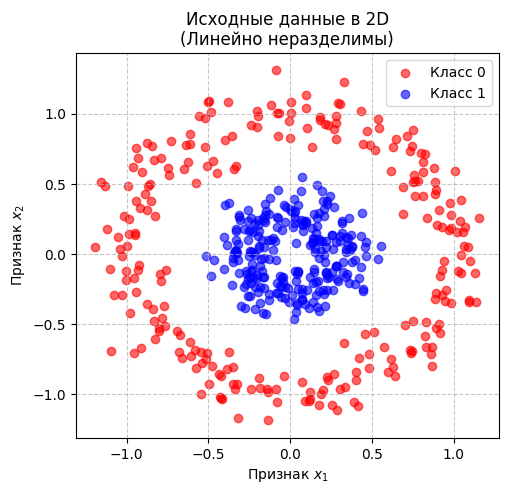

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# 1. Генерируем данные (два кольца)
X, y = make_circles(n_samples=500, factor=0.3, noise=0.1, random_state=42)

# 2. Визуализация в 2D
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', alpha=0.6, label='Класс 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', alpha=0.6, label='Класс 1')
plt.title("Исходные данные в 2D\n(Линейно неразделимы)")
plt.xlabel("Признак $x_1$")
plt.ylabel("Признак $x_2$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

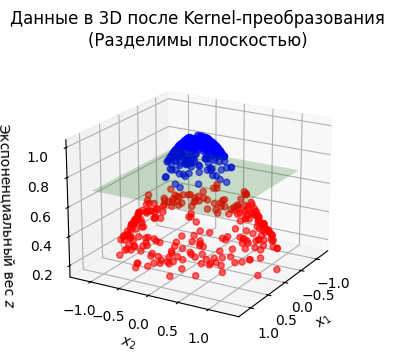

In [ ]:
z = np.exp(-(X[:, 0]**2 + X[:, 1]**2))

ax = plt.subplot(1, 2, 2, projection='3d')
ax.scatter(X[y==0, 0], X[y==0, 1], z[y==0], color='red', alpha=0.6)
ax.scatter(X[y==1, 0], X[y==1, 1], z[y==1], color='blue', alpha=0.6)

# Рисуем "разделяющую гиперплоскость" в 3D
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 10), np.linspace(-1.1, 1.1, 10))
zz = np.full(xx.shape, 0.7) # Плоскость на уровне высоты 0.7
ax.plot_surface(xx, yy, zz, alpha=0.2, color='green')

ax.set_title("Данные в 3D после Kernel-преобразования\n(Разделимы плоскостью)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("Экспоненциальный вес $z$")
ax.view_init(elev=20, azim=30) # Поворачиваем для наглядности

plt.tight_layout()
plt.show()

In [ ]:
def plot_svc_decision(clf, title):
    # Сетка для отрисовки
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
    Z = clf.decision_function(np.c_[xx.flatten(), yy.flatten()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-1000, 0, 1000], alpha=0.2, colors=['red', 'green'])
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2) # Граница
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlGn, edgecolors='k')
    plt.title(title)
    plt.show()

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from ipywidgets import interact, FloatLogSlider, IntSlider

def interactive_poly_svm(degree, C):
    clf = svm.SVC(kernel='poly', degree=degree, C=C, coef0=1).fit(X, y)

    plt.figure(figsize=(8, 6))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.2, colors=['red', 'green'])
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlGn, edgecolors='k')

    plt.title(fr"Polynomial Kernel: degree={degree}, $C$={C:.1f}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()

interact(interactive_poly_svm,
         degree=IntSlider(value=3, min=1, max=10, step=1, description='degree'),
         C=FloatLogSlider(value=1.0, base=10, min=-2, max=3, step=0.1, description='C'))

interactive(children=(IntSlider(value=3, description='degree', max=10, min=1), FloatLogSlider(value=1.0, descr…

<function __main__.interactive_poly_svm(degree, C)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from ipywidgets import interact, FloatLogSlider

def interactive_svm(gamma, C):

    clf = svm.SVC(kernel='rbf', gamma=gamma, C=C).fit(X, y)

    plt.figure(figsize=(8, 6))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.2, colors=['red', 'green'])
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlGn, edgecolors='k')

    plt.title(fr"RBF Kernel: $\gamma$={gamma:.3f}, $C$={C:.1f}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()

# Создаем интерактивные ползунки
interact(interactive_svm,
         gamma=FloatLogSlider(value=1.0, base=10, min=-3, max=3, step=0.1, description='gamma'),
         C=FloatLogSlider(value=1.0, base=10, min=-2, max=3, step=0.1, description='C'))

interactive(children=(FloatLogSlider(value=1.0, description='gamma', max=3.0, min=-3.0), FloatLogSlider(value=…

<function __main__.interactive_svm(gamma, C)>